In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("processed_wall_following_data A3.csv")

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(5456, 3)
front_distance    float64
left_distance     float64
action             object
dtype: object
front_distance    0
left_distance     0
action            0
dtype: int64


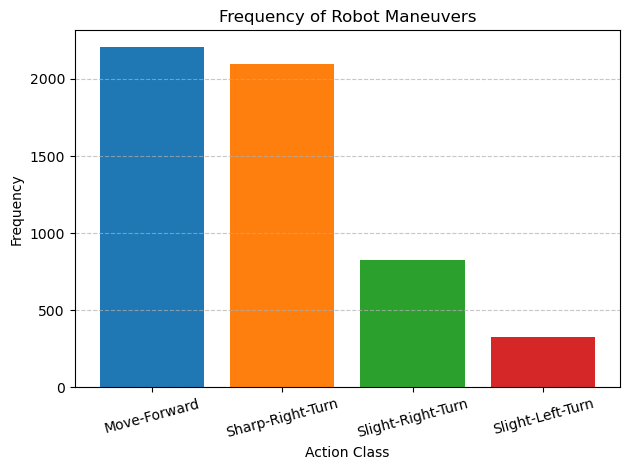

In [ ]:
import matplotlib.pyplot as plt
order = ['Move-Forward', 'Sharp-Right-Turn', 'Slight-Right-Turn', 'Slight-Left-Turn']
class_counts = df['action'].value_counts()
counts = [class_counts.get(cls, 0) for cls in order]

plt.bar(order, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Frequency of Robot Maneuvers')
plt.xlabel('Action Class')
plt.ylabel('Frequency')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

Behavioral Bias Explanation

If this imbalance is not addressed, the robot's behavior will be biased in the following ways:

Majority Class Overfitting: The neural network will become highly proficient at predicting "Move-Forward" and "Sharp-Right-Turn" because these samples dominate the loss calculation. The robot may default to moving forward even when a subtle adjustment is required.

Poor Minority Class Performance: Because "Slight-Left-Turn" represents a small fraction of the data, the model will likely treat these instances as noise. Consequently, the robot may fail to navigate specific corridor configurations that require leftward corrections, leading to collisions with the right wall.

False High Accuracy: The model might report high overall accuracy (since it predicts the common classes well), but it will be unreliable in critical "edge-case" scenarios that require the less-frequent maneuvers.

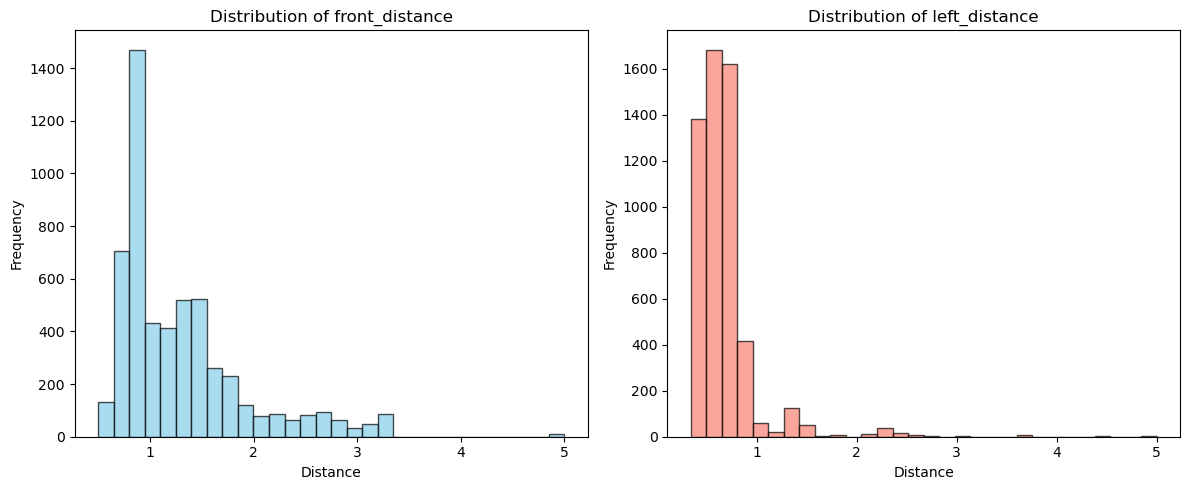

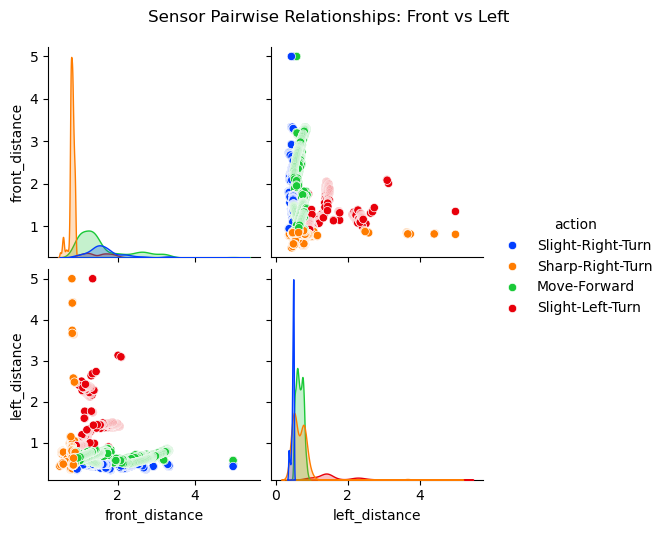

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sensors = ['front_distance', 'left_distance']
target = 'action'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['skyblue', 'salmon']

for i, sensor in enumerate(sensors):
    axes[i].hist(df[sensor], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {sensor}')
    axes[i].set_xlabel('Distance')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
sns.pairplot(df, vars=sensors, hue=target, palette='bright', diag_kind='kde')
plt.suptitle('Sensor Pairwise Relationships: Front vs Left', y=1.05)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
sensors = ['front_distance', 'left_distance']
X = df[sensors]
y = df['action']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
pipeline = Pipeline([('scaler', StandardScaler()),])

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

print("\nScaling complete")


Scaling complete


Why Scaling is Mathematically Necessary for Gradient Descent:

Neural networks, specifically Multi-Layer Perceptrons (MLPs), use Gradient Descent to minimize the loss function.

Scaling is critical because:

Uniform Feature Influence: If one sensor (e.g., Front) has a range of $0-500$ and another (e.g., Left) has a range of $0-1$, the weights associated with the larger range will dominate the gradient updates. This makes the model "biased" toward larger-scale features.

Faster Convergence: Scaled data makes the cost function more "spherical." This allows gradient descent to take a direct path toward the global minimum, significantly speeding up training time and preventing the model from getting stuck in poor local minima.

C:\Users\HP\Downloads\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


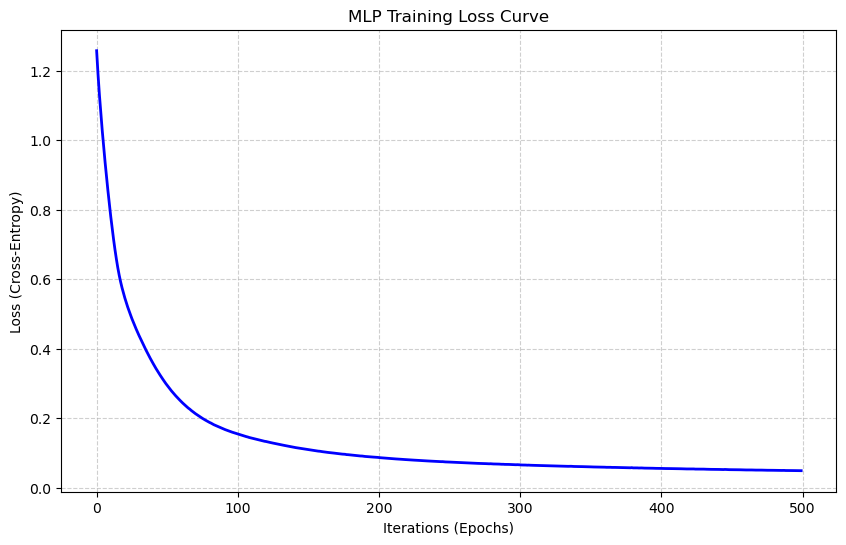

Final training loss: 0.0489


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(16,),  # One hidden layer with 16 neurons
    activation='relu',         # Hidden layer activation
    solver='adam',             # Efficient optimizer for gradient descent
    random_state=42,           # Fixed seed for reproducibility
    max_iter=500,              # Give it enough iterations to converge
    verbose=False
)
model_pipeline = Pipeline([ ('scaler', StandardScaler()),('mlp', mlp)])
model_pipeline.fit(X_train, y_train)
plt.figure(figsize=(10, 6))
plt.plot(model_pipeline.named_steps['mlp'].loss_curve_, color='blue', lw=2)
plt.title('MLP Training Loss Curve')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Loss (Cross-Entropy)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Final training loss: {model_pipeline.named_steps['mlp'].loss_curve_[-1]:.4f}")

In [ ]:
from sklearn.model_selection import GridSearchCV
import joblib

param_grid = {
    'mlp__hidden_layer_sizes': [(16,), (32,), (16, 16)],
    'mlp__learning_rate_init': [0.001, 0.01],
    'mlp__alpha': [0.0001, 0.001, 0.01],
}

# Use the pipeline from Part 3 as the estimator
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'robot_model_pipeline.pkl')
print("Model saved successfully as robot_model_pipeline.pkl")

Best Parameters: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (16, 16), 'mlp__learning_rate_init': 0.001}
Model saved successfully as robot_model_pipeline.pkl


Test Set Accuracy: 0.9982

--- Classification Report ---
                   precision    recall  f1-score   support

     Move-Forward       1.00      1.00      1.00       441
 Sharp-Right-Turn       1.00      1.00      1.00       420
 Slight-Left-Turn       1.00      1.00      1.00        66
Slight-Right-Turn       0.99      1.00      0.99       165

         accuracy                           1.00      1092
        macro avg       1.00      1.00      1.00      1092
     weighted avg       1.00      1.00      1.00      1092



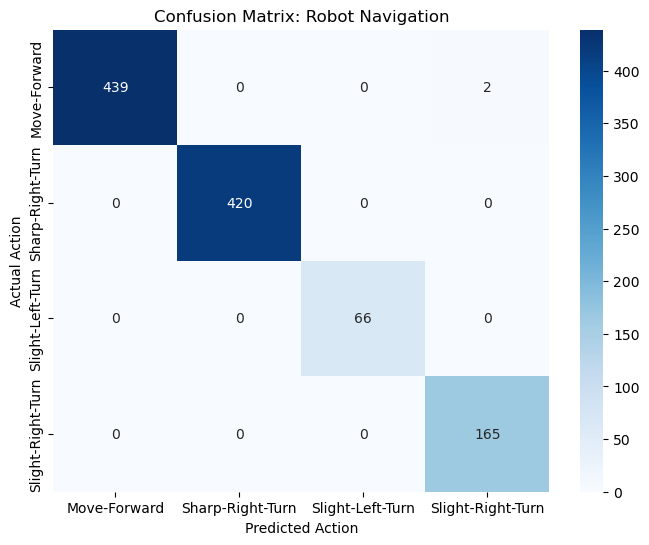

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix: Robot Navigation')
plt.xlabel('Predicted Action')
plt.ylabel('Actual Action')
plt.show()

In [ ]:
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Difference: {abs(train_acc - test_acc):.4f}")


Training Accuracy: 0.9950
Test Accuracy: 0.9982
Difference: 0.0032


The modal is generalizing well as both accuracies are high and within $2-3\%$ of each other, the model is healthy. It has learned the underlying patterns of wall-following rather than just the specific data points.

FOR RUNNING ROS NODE

python3 robot.py

ros2 topic pub -1 /ultrasonic_sensors std_msgs/msg/Float32MultiArray "{data: [0.5, 0.1]}"

ros2 topic echo /cmd_vel